<a href="https://colab.research.google.com/github/WooyeongJang/ml-with-pytorch/blob/main/1%EC%A3%BC%EC%B0%A8_%EA%B0%95%EC%9D%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#수업 환경 확인

- 권장 패키지 버전
```
'numpy': '1.21.2'
'pandas': '1.3.2'
'matplotlib': '3.4.3'
```

In [ ]:
import sys, numpy, pandas, matplotlib

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0


In [ ]:
# sep 기본 옵셥 ' ' 공백 한칸
print("A","B")
print("A","B", sep='|')
print("A","B", sep='')
# end 기본 옵션 \n  줄바꿈
print("A","B", end ='')
print("A","B", sep='|', end='')
print("A","B", sep='')

A B
A|B
AB
A BA|BAB


In [ ]:
import numpy as np


class Perceptron:
    """퍼셉트론 분류기

    매개변수
    ------------
    eta : float
      학습률 (0.0과 1.0 사이)
    n_iter : int
      훈련 데이터셋 반복 횟수
    random_state : int
      가중치 무작위 초기화를 위한 난수 생성기 시드

    속성
    -----------
    w_ : 1d-array
      학습된 가중치
    b_ : 스칼라
      학습된 절편 유닛
    errors_ : list
      에포크마다 누적된 분류 오류
    """

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """훈련 데이터 학습

        매개변수
        ----------
        X : array-like, shape = [n_samples, n_features]
          n_samples개의 샘플과 n_features개의 특성으로 이루어진 훈련 데이터
        y : array-like, shape = [n_samples]
          타깃값

        반환값
        -------
        self : object
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = 0.0
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)

        return self

    def net_input(self, X):
        """입력 계산"""
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        """단위 계단 함수를 사용하여 클래스 레이블을 반환합니다"""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

In [ ]:
import numpy as np

# 간단한 AND 게이트 데이터 (-1, 1 레이블)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([-1, -1, -1, 1])

ppn = Perceptron(eta=0.1, n_iter=10, random_state=1)
ppn.fit(X, y)

print("=== 학습된 가중치 ===")
print("w_:", ppn.w_)
print("b_:", ppn.b_)

print("\n=== 에포크별 에러 수 ===")
for epoch, err in enumerate(ppn.errors_, start=1):
    print(f"Epoch {epoch}: errors = {err}")

# 수렴 시점 찾기
converged_epoch = next((i+1 for i, e in enumerate(ppn.errors_) if e == 0), None)
print("\n수렴 에포크:", converged_epoch)

print("\n=== 샘플별 예측 결과 ===")
for xi, target in zip(X, y):
    pred = ppn.predict(xi)
    net = ppn.net_input(xi)
    print(f"입력: {xi}, net_input: {net:.4f}, 예측: {pred}, 실제: {target}")

predictions = ppn.predict(X)

print("\n=== 전체 예측 결과 ===")
print("Predictions:", predictions)
print("Ground Truth:", y)

print("\n=== 단위 테스트 검증 ===")

# 1. 예측 정확성 검증
assert np.array_equal(predictions, y), "예측값이 실제값과 다릅니다."
print("✔ 예측 정확성 통과")

# 2. 에포크 수 검증 (현재 구현은 조기종료 없음)
assert len(ppn.errors_) == ppn.n_iter, "errors_ 길이가 n_iter와 다릅니다."
print("✔ 에포크 저장 길이 검증 통과")

# 3. 수렴 여부 검증 (최소 한 번은 0이어야 정상 수렴)
assert any(e == 0 for e in ppn.errors_), "수렴하지 않았습니다."
print("✔ 수렴 여부 검증 통과")

# 4. 타입 검증
assert isinstance(ppn.w_, np.ndarray), "w_ 타입 오류"
assert isinstance(ppn.b_, (float, np.floating)), "b_ 타입 오류"
print("✔ 파라미터 타입 검증 통과")

print("\n🎉 모든 단위 테스트 통과")

=== 학습된 가중치 ===
w_: [0.21624345 0.19388244]
b_: -0.4

=== 에포크별 에러 수 ===
Epoch 1: errors = 2
Epoch 2: errors = 3
Epoch 3: errors = 1
Epoch 4: errors = 0
Epoch 5: errors = 0
Epoch 6: errors = 0
Epoch 7: errors = 0
Epoch 8: errors = 0
Epoch 9: errors = 0
Epoch 10: errors = 0

수렴 에포크: 4

=== 샘플별 예측 결과 ===
입력: [0 0], net_input: -0.4000, 예측: -1, 실제: -1
입력: [0 1], net_input: -0.2061, 예측: -1, 실제: -1
입력: [1 0], net_input: -0.1838, 예측: -1, 실제: -1
입력: [1 1], net_input: 0.0101, 예측: 1, 실제: 1

=== 전체 예측 결과 ===
Predictions: [-1 -1 -1  1]
Ground Truth: [-1 -1 -1  1]

=== 단위 테스트 검증 ===
✔ 예측 정확성 통과
✔ 에포크 저장 길이 검증 통과
✔ 수렴 여부 검증 통과
✔ 파라미터 타입 검증 통과

🎉 모든 단위 테스트 통과


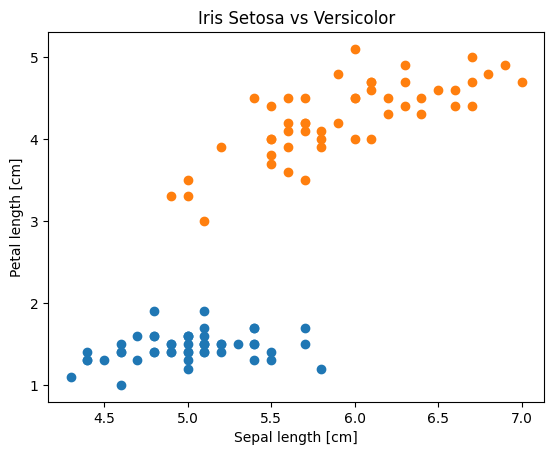

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# ==============================
# 🌸 Iris 데이터 기본 정보
# ------------------------------
# 전체 샘플 수: 150개
# 클래스 수: 3개
#   0 → Setosa (50개)
#   1 → Versicolor (50개)
#   2 → Virginica (50개)
#
# 각 클래스는 순서대로 정렬되어 있음:
#   0~49   : Setosa
#   50~99  : Versicolor
#   100~149: Virginica
#
# iris.data 구조:
#   열 0 → Sepal length (꽃받침 길이)
#   열 1 → Sepal width  (꽃받침 너비)
#   열 2 → Petal length (꽃잎 길이)
#   열 3 → Petal width  (꽃잎 너비)
# ==============================

# Iris 데이터 로드
iris = datasets.load_iris()

# 처음 100개 샘플만 사용 → Setosa(0) + Versicolor(1)
X = iris.data[:100, [0, 2]]  # Sepal length, Petal length
y = iris.target[:100]

# 산점도
plt.figure()
plt.scatter(X[y == 0, 0], X[y == 0, 1])
plt.scatter(X[y == 1, 0], X[y == 1, 1])

plt.xlabel("Sepal length [cm]")
plt.ylabel("Petal length [cm]")
plt.title("Iris Setosa vs Versicolor")

plt.show()

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

# 1. Iris 데이터 로드
iris = datasets.load_iris()

# Setosa(0) vs Versicolor(1)만 사용
X = iris.data[:100, [0, 2]]  # sepal length, petal length
y = iris.target[:100]

# 레이블을 -1, 1로 변환
y = np.where(y == 0, -1, 1)

# 2. Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# 3. 퍼셉트론 학습
ppn = Perceptron(eta=0.01, n_iter=10, random_state=1)
ppn.fit(X_train, y_train)

# 4. 학습 결과 출력
print("=== 학습된 가중치 ===")
print("w_:", ppn.w_)
print("b_:", ppn.b_)

print("\n=== 에포크별 에러 수 ===")
for epoch, err in enumerate(ppn.errors_, start=1):
    print(f"Epoch {epoch}: errors = {err}")

# 5. 테스트 데이터 평가
y_pred = ppn.predict(X_test)
accuracy = np.mean(y_pred == y_test)

print("\n=== 테스트 결과 ===")
print("정확도:", accuracy)
print("예측값:", y_pred[:10])
print("실제값:", y_test[:10])

=== 학습된 가중치 ===
w_: [-0.03575655  0.08588244]
b_: -0.02

=== 에포크별 에러 수 ===
Epoch 1: errors = 5
Epoch 2: errors = 0
Epoch 3: errors = 0
Epoch 4: errors = 0
Epoch 5: errors = 0
Epoch 6: errors = 0
Epoch 7: errors = 0
Epoch 8: errors = 0
Epoch 9: errors = 0
Epoch 10: errors = 0

=== 테스트 결과 ===
정확도: 1.0
예측값: [ 1  1 -1 -1 -1  1  1  1 -1 -1]
실제값: [ 1  1 -1 -1 -1  1  1  1 -1 -1]


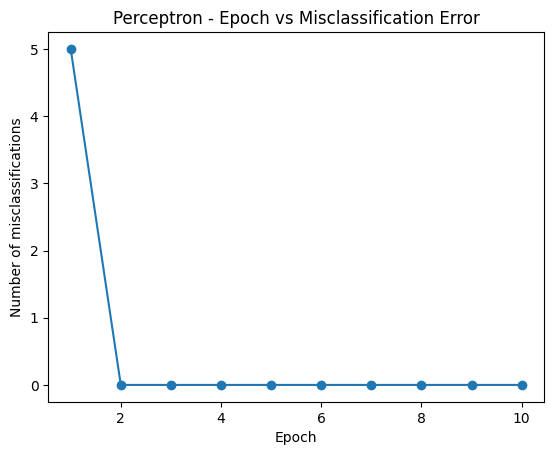

In [ ]:
import matplotlib.pyplot as plt

# 에포크 대비 오분류 오차 그래프
plt.figure()
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Number of misclassifications")
plt.title("Perceptron - Epoch vs Misclassification Error")

plt.show()

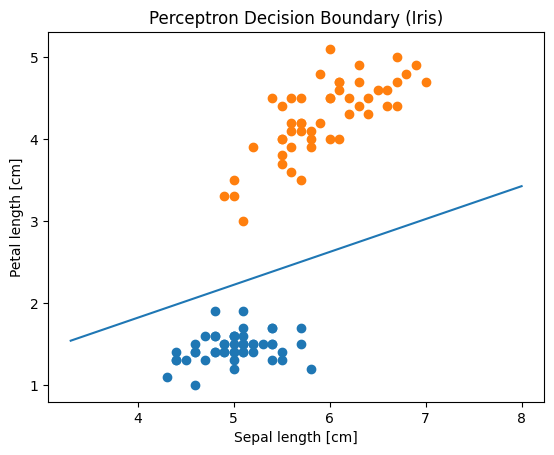

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# Iris 데이터 로드
iris = datasets.load_iris()
X = iris.data[:100, [0, 2]]  # sepal length, petal length
y = iris.target[:100]
y = np.where(y == 0, -1, 1)

# 퍼셉트론 학습 (이미 학습했다면 생략 가능)
ppn = Perceptron(eta=0.1, n_iter=10, random_state=1)
ppn.fit(X, y)

# 산점도
plt.figure()
plt.scatter(X[y == -1, 0], X[y == -1, 1])
plt.scatter(X[y == 1, 0], X[y == 1, 1])

# 결정 경계 계산
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_vals = np.linspace(x_min, x_max, 100)

# w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b)/w2
w1, w2 = ppn.w_
b = ppn.b_

y_vals = -(w1 * x_vals + b) / w2

plt.plot(x_vals, y_vals)

plt.xlabel("Sepal length [cm]")
plt.ylabel("Petal length [cm]")
plt.title("Perceptron Decision Boundary (Iris)")

plt.show()

In [1]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 데이터 로드
X, y = load_iris(return_X_y=True)

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 퍼셉트론 모델 생성
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)

# 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 정확도
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4666666666666667


In [4]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# 데이터 로드
X, y = load_iris(return_X_y=True)

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 퍼셉트론 모델 생성
model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, eta0=0.1, random_state=42)
)
# 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 정확도
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7666666666666667


In [5]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# 데이터 로드
X, y = load_iris(return_X_y=True)

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 퍼셉트론 모델 생성
model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, eta0=0.01, random_state=42)
)
# 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 정확도
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8333333333333334


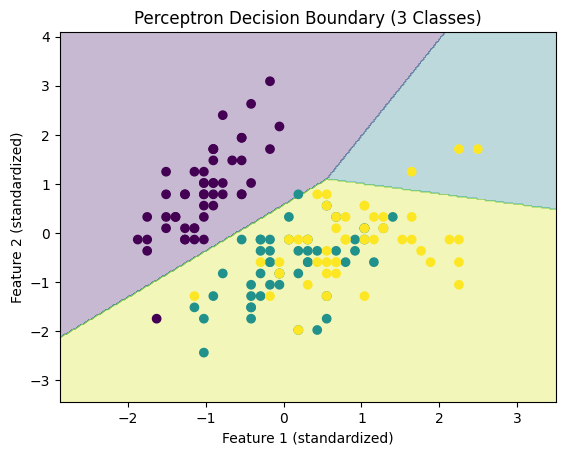

In [6]:
# Decision Boundary Visualization for 3-class Perceptron (using 2 features)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = load_iris()
X = iris.data[:, :2]  # Use first two features for 2D visualization
y = iris.target

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Perceptron
model = Perceptron(max_iter=1000, eta0=0.01, random_state=42)
model.fit(X_scaled, y)

# Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot (single plot, no specific colors)
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.title("Perceptron Decision Boundary (3 Classes)")
plt.show()

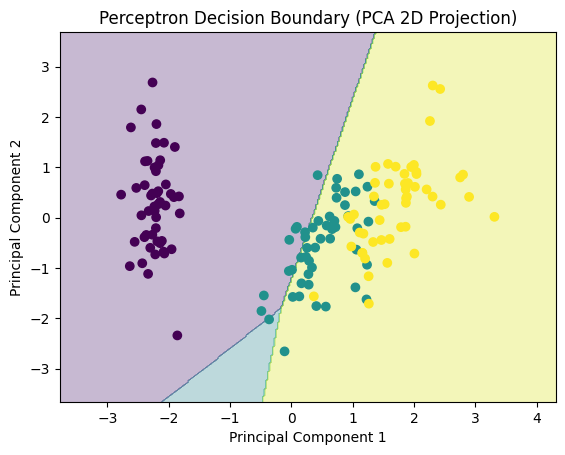

Explained variance ratio: [0.72962445 0.22850762]


In [7]:
# PCA-based 2D Decision Boundary Visualization (using all 4 features)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train Perceptron on PCA-transformed data
model = Perceptron(max_iter=1000, eta0=0.01, random_state=42)
model.fit(X_pca, y)

# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on mesh grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot (single plot, no specific colors)
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary (PCA 2D Projection)")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)